# MNIST Neural Network Component Runner
This notebook orchestrates the training of your ANN components module by module.

### 1. Setup and Imports

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src.config import *
from src.data_utils import load_mnist_data, preprocess_mnist
from src.train_utils import fit, LRScheduler
from src.metrics import plot_bias_variance_tracking
from src.network import NeuralNetwork
from src.layers import Dense, BatchNorm, LayerNorm
from src.activations import ReLU, Sigmoid, Softmax, plot_activation_functions
from src.losses import CrossEntropyLoss
from src.optimizers import GradientDescent, AdamOptimizer

### 2. Load and Preprocess Data (Fully Working)

In [2]:
np.random.seed(RANDOM_SEED)
X, y = load_mnist_data()
X_train, X_val, y_train, y_val = preprocess_mnist(X, y)
print("Data loaded and preprocessed!")

Fetching MNIST data... this may take a moment.
Data loaded and preprocessed!


### 3. Visualize Samples

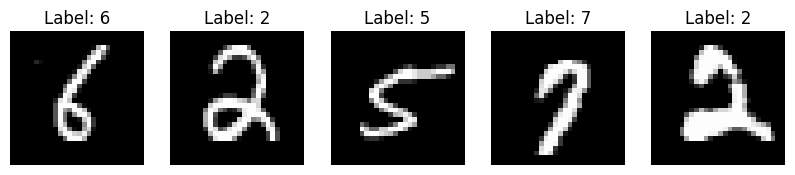

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    sample_idx = np.random.randint(0, X_train.shape[0])
    img = X_train[sample_idx].reshape(28, 28)
    label = np.argmax(y_train[sample_idx])
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.show()

### 4. Initialize Model Pipeline

In [ ]:
model = NeuralNetwork()

# TODO (M1): Verify forward shapes by running a dummy batch
model.add(Dense(INPUT_DIM, HIDDEN_DIM, init_type="he"))
# TODO (M16): You can inject Normalization layers here later
# model.add(BatchNorm(HIDDEN_DIM))
model.add(ReLU())
# TODO (M14): Add Dropout here later
# model.add(Dropout(0.5))

model.add(Dense(HIDDEN_DIM, OUTPUT_DIM, init_type="xavier"))

loss_fn = CrossEntropyLoss()
# TODO (M9): Swap out GradientDescent for AdamOptimizer later
optimizer = GradientDescent(lr=LEARNING_RATE)

In [ ]:
# TODO (M4): Run Gradient Check here
# e.g. verify analytic dW vs numerical dW using a tiny dummy output

### 5. Training Loop Call

In [ ]:
history = fit(
    model=model, 
    loss_fn=loss_fn, 
    optimizer=optimizer, 
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE
)

### 6. Plot Metrics & Visualization Hooks

In [ ]:
# TODO (M15): Replace below with your implemented plot_bias_variance_tracking(history)
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss Curve')
plt.legend()
plt.show()

# TODO (M6): Plot gradient norms per layer over time using model.grad_magnitudes

# TODO (M10): Plot LR schedule if you used a dynamic scheduler

# TODO (M11): Visualize loss surface (optional stub)


### 7. Predictions Visualization

In [ ]:
test_samples = X_val[:5]
true_labels = np.argmax(y_val[:5], axis=1)
try:
    predictions = model.forward(test_samples, is_training=False)
    pred_labels = np.argmax(predictions, axis=1)
except Exception as e:
    print("Error in forward pass.")
    pred_labels = ["TODO"] * 5

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    img = test_samples[i].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}")
    axes[i].axis('off')
plt.show()